# Clustering embeddings

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

scratch_dir = "~/scratch/birdclef/data/2025"
model_name = "Perch"
embed_dir = f"{scratch_dir}/train_audio-infer-soundscape/{model_name}/parts/embed/"


def load_metadata(input_path: str) -> pd.DataFrame:
    df = pd.read_parquet(input_path, columns=["file"])
    # extract species_name
    df["species_name"] = df["file"].apply(
        lambda x: x.split("train_audio/")[1].split("/")[0]
    )
    # train/test split requries y label to have at least 2 samples
    # remove species with less than 2 samples
    species_count = df["species_name"].value_counts()
    valid_species = species_count[species_count >= 2].index
    df = df[df["species_name"].isin(valid_species)].reset_index(drop=True)
    return df


df = pd.read_parquet(embed_dir)
meta_df = load_metadata(embed_dir)
display(df.head(5))
display(df.shape)
display(meta_df.head(5))

,file,start_time,end_time,0,1,2,3,4,5,6,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
0,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,0.0,5.0,0.035193,0.312198,-0.163250,-0.184991,0.106889,0.084568,-0.188817,...,0.058502,0.055137,0.368951,0.033166,-0.196700,-0.164068,0.628766,0.445605,0.402375,-0.124598
1,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,5.0,10.0,-0.049977,-0.035013,0.028650,-0.031749,-0.051740,-0.105892,-0.032433,...,-0.081018,0.087219,-0.095684,-0.102721,0.003947,0.008007,0.074437,0.092539,0.071778,0.107605
2,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,10.0,15.0,-0.012233,-0.025818,-0.022986,-0.012629,-0.043897,0.001670,0.022503,...,-0.028815,0.083117,-0.073288,-0.082449,0.013737,-0.009788,0.031396,0.034211,0.100053,-0.022362
3,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,15.0,20.0,-0.027199,-0.029883,-0.007902,-0.017360,-0.070084,-0.052606,-0.009501,...,-0.025455,-0.015810,-0.059842,0.002440,-0.013438,-0.026338,0.118346,0.022114,0.113497,-0.011001
4,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,20.0,25.0,-0.065667,-0.083267,-0.009503,-0.022486,-0.043911,-0.067285,0.006144,...,-0.086033,0.023396,-0.135187,-0.096632,0.005010,0.006353,-0.026329,0.041473,0.090269,-0.023513


(187839, 1283)

,file,species_name
0,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,1139490
1,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,1139490
2,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,1139490
3,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,1139490
4,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,1139490


In [3]:
def load_preprocess_data(input_path: str) -> pd.DataFrame:
    df = pd.read_parquet(input_path)
    # concatenate all embeddings into a single DataFrame
    df["species_name"] = df["file"].apply(
        lambda x: x.split("train_audio/")[1].split("/")[0]
    )
    # train/test split requries y label to have at least 2 samples
    # remove species with less than 2 samples
    species_count = df["species_name"].value_counts()
    valid_species = species_count[species_count >= 2].index
    filtered_df = df[df["species_name"].isin(valid_species)].reset_index(drop=True)
    # concatenate embeddings
    non_embed_cols = {"file", "start_time", "end_time", "species_name"}
    embed_cols = [col for col in filtered_df.columns if col not in non_embed_cols]
    filtered_df["embeddings"] = list(filtered_df[embed_cols].to_numpy())
    df_embs = filtered_df[["species_name", "embeddings"]].copy()
    print(f"DataFrame shape: {df_embs.shape}")
    print(f"Embedding size: {len(df_embs['embeddings'].iloc[0])}")
    return df_embs

In [4]:
df_embs = load_preprocess_data(embed_dir)
display(df_embs.head(5))
df_embs.shape

DataFrame shape: (187838, 2)
Embedding size: 1280


,species_name,embeddings
0,1139490,"[0.035192787647247314, 0.312198281288147, -0.1..."
1,1139490,"[-0.04997699335217476, -0.03501279279589653, 0..."
2,1139490,"[-0.01223329920321703, -0.025818223133683205, ..."
3,1139490,"[-0.027199307456612587, -0.029882565140724182,..."
4,1139490,"[-0.06566715240478516, -0.08326669782400131, -..."


(187838, 2)

In [5]:
df_embs["species_name"].value_counts().head(20)

species_name
compau     6099
grekis     5464
roahaw     5262
whtdov     4988
laufal1    4853
trokin     4591
yercac1    4005
trsowl     3866
banana     3769
wbwwre1    3566
gycwor1    3454
socfly1    3347
yeofly1    3334
bobfly1    3101
strcuc1    2862
saffin     2819
sobtyr1    2671
bkmtou1    2652
blbgra1    2615
bubwre1    2600
Name: count, dtype: int64

In [6]:
# average the embeddings for each species
def average_embeddings(df: pd.DataFrame) -> pd.DataFrame:
    avg_df = (
        df.groupby("species_name")["embeddings"]
        .apply(lambda x: np.mean(np.array(x).tolist(), axis=0))
        .reset_index()
    )
    avg_df.columns = ["species_name", "avg_embedding"]
    return avg_df


avg_df = average_embeddings(df_embs)
display(avg_df.head(5))
avg_df.shape

,species_name,avg_embedding
0,1139490,"[-0.024498414649554576, -0.0494209150048463, -..."
1,1192948,"[-0.015752888943842917, -0.06041880911117958, ..."
2,1194042,"[0.008600247357903486, -0.03169718006735339, -..."
3,126247,"[0.13332337764201357, 0.01752038420561482, 0.0..."
4,1346504,"[0.03688434607559635, -0.040050355948844825, 0..."


(204, 2)

In [7]:
import pacmap
from sklearn.preprocessing import StandardScaler


def get_pandas_embeddings(df: pd.DataFrame, col_name: str) -> np.ndarray:
    # Extract features and labels
    emb_df = np.stack(df[col_name].values)
    scaled_emb = StandardScaler().fit_transform(emb_df)

    # UMAP reduction
    reducer = pacmap.PaCMAP(n_components=2, random_state=42)
    embeddings = reducer.fit_transform(
        scaled_emb
    )  # NumPy array with shape (n_samples, 2)
    return embeddings

In [8]:
avg_embeds = get_pandas_embeddings(avg_df, "avg_embedding")
avg_embeds.shape

(204, 2)

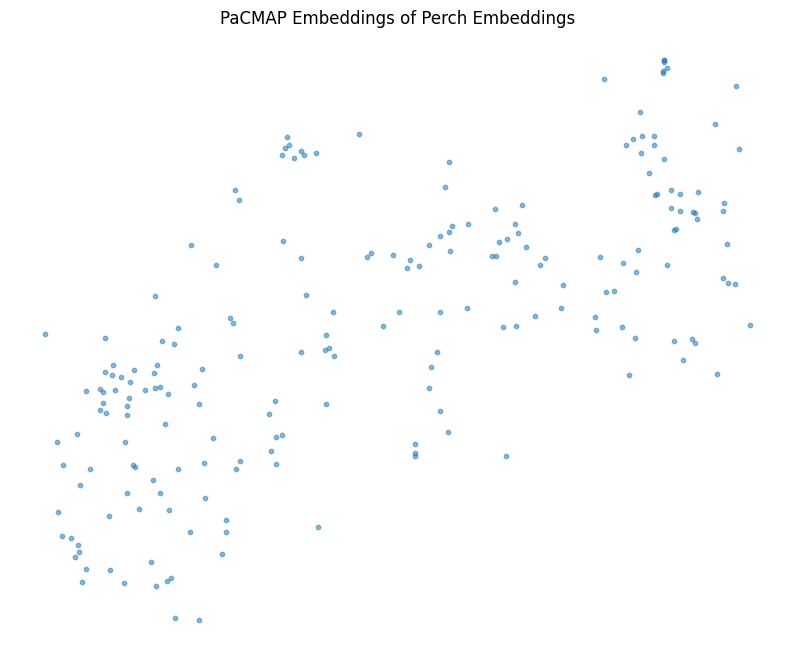

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(avg_embeds[:, 0], avg_embeds[:, 1], s=10, alpha=0.5)
plt.title("PaCMAP Embeddings of Perch Embeddings")
plt.axis("off")
plt.show()

In [11]:
# filter only top 20 species
top10_species = df_embs["species_name"].value_counts().head(10).index.tolist()
top10_df = df_embs[df_embs["species_name"].isin(top10_species)].copy()
top10_df.head(10)

,species_name,embeddings
90,banana,"[-0.036543913185596466, -0.07806725800037384, ..."
91,banana,"[-0.10287272185087204, -0.10075721889734268, 0..."
92,banana,"[4.114993134862743e-05, -0.05354055389761925, ..."
93,banana,"[0.28657275438308716, -0.021705878898501396, -..."
94,banana,"[-0.007522060070186853, -0.052960362285375595,..."
95,banana,"[-0.04069487005472183, 0.04132554680109024, -0..."
96,banana,"[-0.04492052271962166, 0.0238773375749588, -0...."
97,banana,"[0.04026984050869942, 0.0016008872771635652, 0..."
98,banana,"[0.020511656999588013, 0.04802454635500908, 0...."
99,banana,"[-0.023496871814131737, 0.013001029379665852, ..."


In [12]:
embeds = get_pandas_embeddings(top10_df, "embeddings")
embeds.shape

(46463, 2)

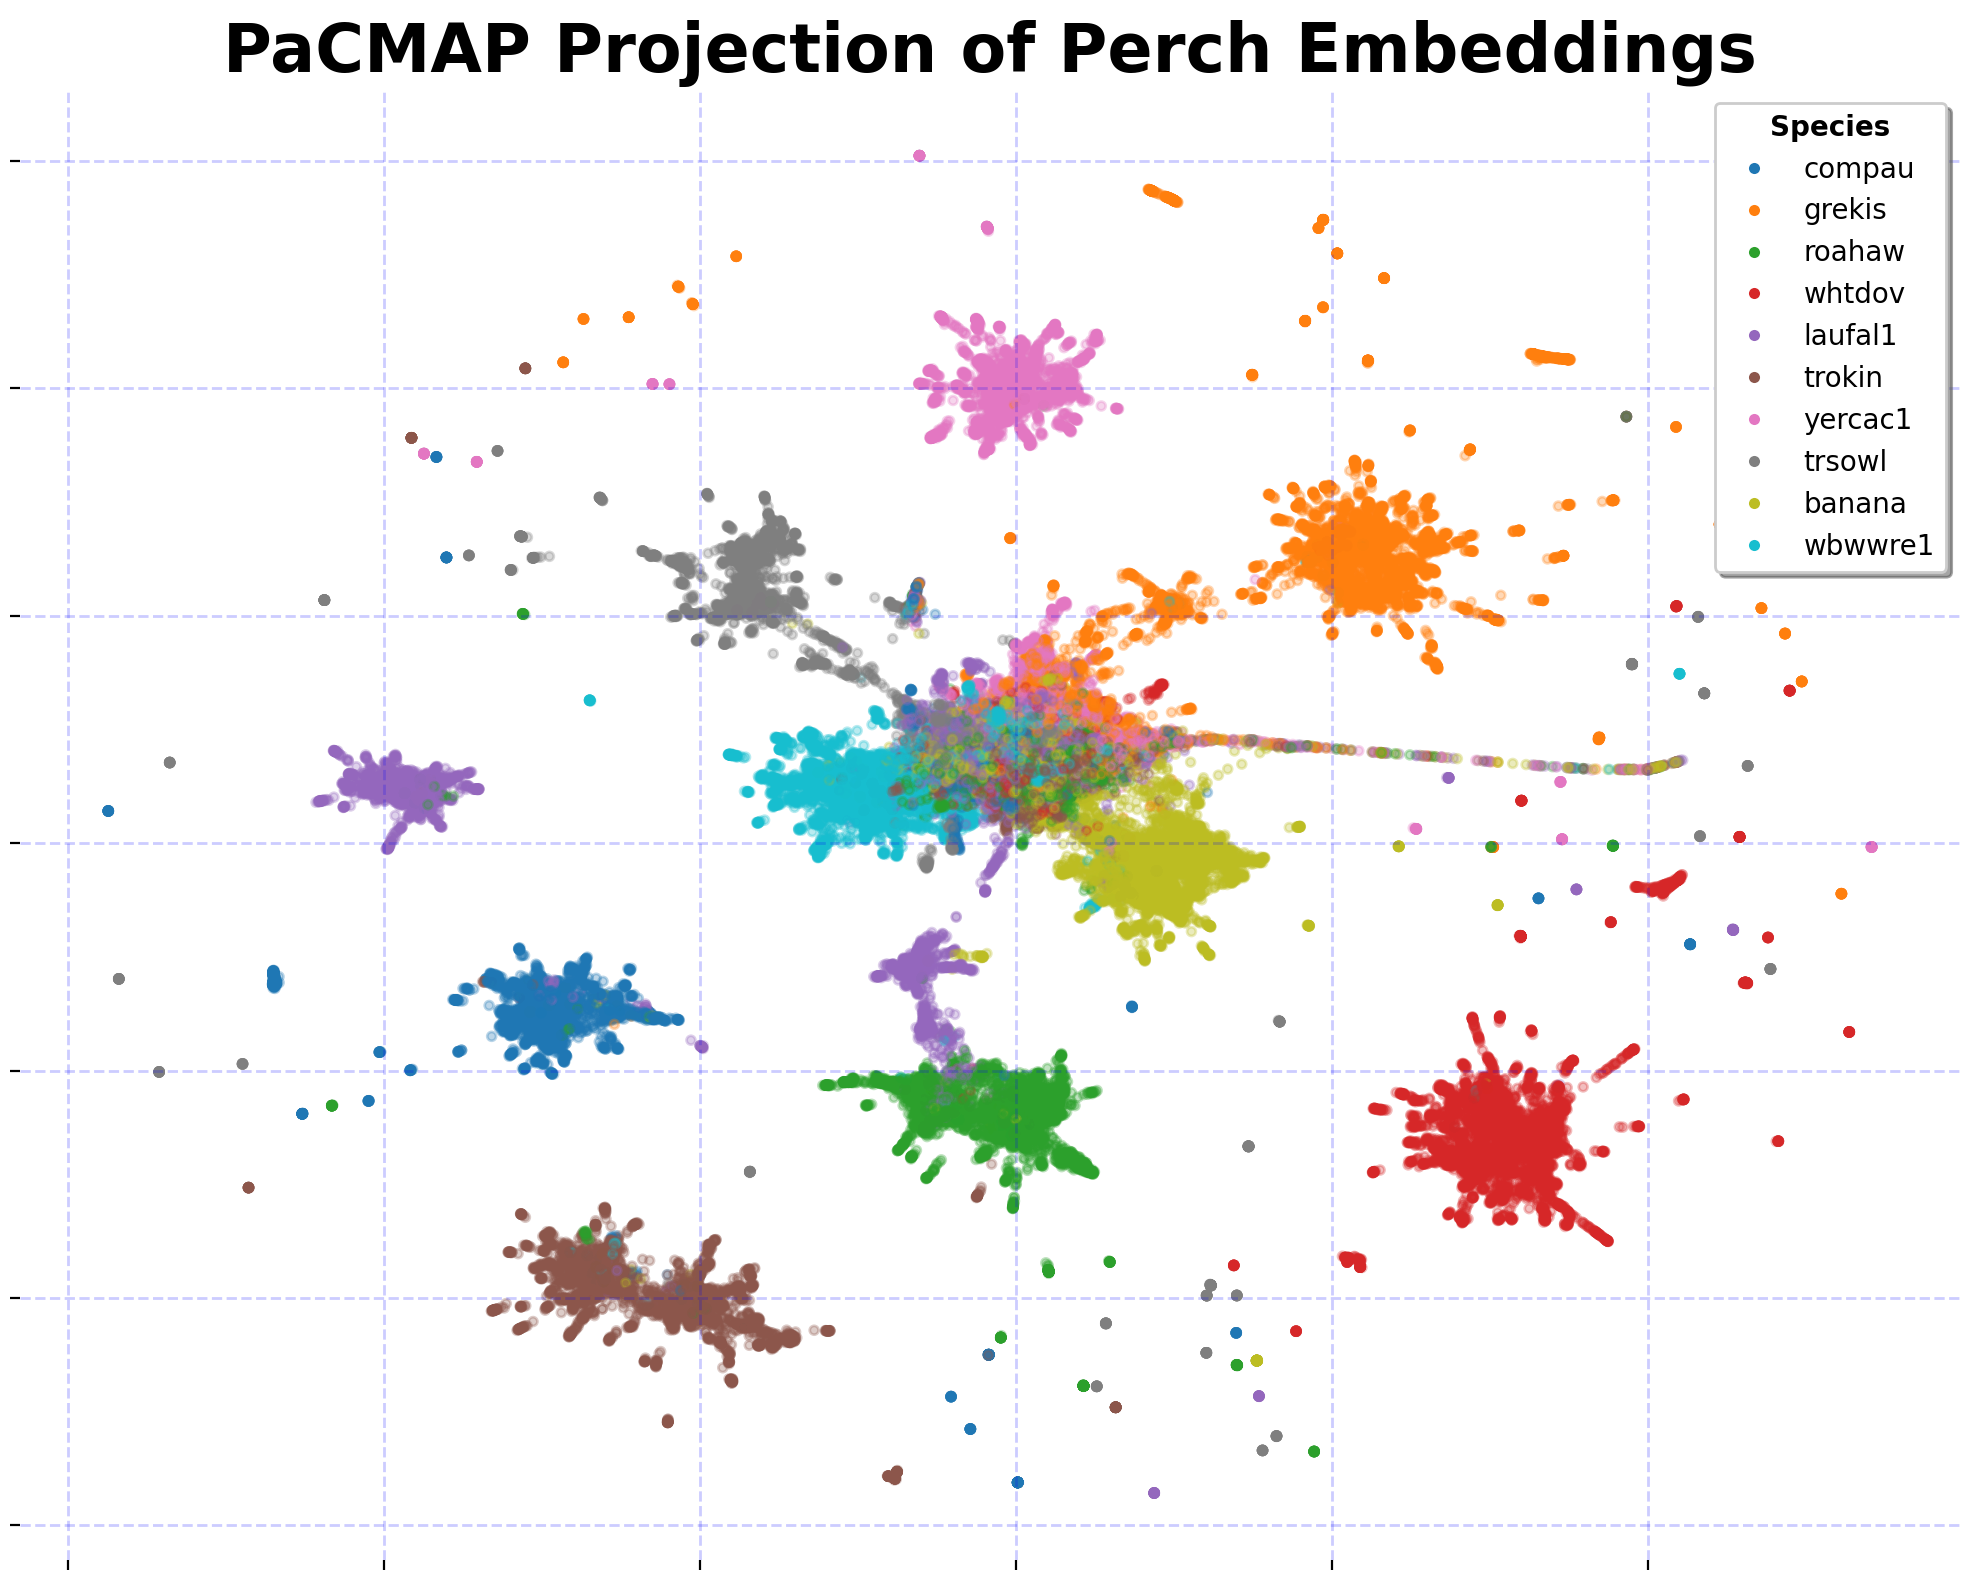

In [40]:
colors = plt.cm.tab10.colors  # Distinct color palette
fig, ax = plt.subplots(figsize=(10, 8), dpi=200)
ax.scatter(
    embeds[:, 0],
    embeds[:, 1],
    s=10,
    alpha=0.3,
    c=top10_df["species_name"].astype("category").cat.codes,
    cmap="tab10",
)
ax.set_title("PaCMAP Projection of Perch Embeddings", weight="bold", fontsize=24)
# plt.axis("off")  # Remove or comment out this line
ax.grid(color="blue", linestyle="--", linewidth=1, alpha=0.2)
ax.legend(
    handles=[
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label=species,
            markersize=5,
            markerfacecolor=color,
        )
        for species, color in zip(top10_species, colors)
    ],
    title="Species",
    title_fontproperties={"weight": "bold"},
    loc="upper right",
    bbox_to_anchor=(1, 1),
    shadow=True,
)
ax.set_xticklabels([])
ax.set_yticklabels([])
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
plt.show()

In [15]:
project_dir = "~/p-dsgt_clef2025-0/shared/birdclef"
soundscapes_dir = f"{project_dir}/2025/infer-soundscape/{model_name}/parts/embed"


def load_metadata(input_path: str) -> pd.DataFrame:
    df = pd.read_parquet(input_path, columns=["file"])
    # extract species_name
    df["species_name"] = df["file"].apply(
        lambda x: x.split("train_audio/")[1].split("/")[0]
    )
    # train/test split requries y label to have at least 2 samples
    # remove species with less than 2 samples
    species_count = df["species_name"].value_counts()
    valid_species = species_count[species_count >= 2].index
    df = df[df["species_name"].isin(valid_species)].reset_index(drop=True)
    return df


sound_df = pd.read_parquet(soundscapes_dir)
display(sound_df.head(5))
sound_df.shape

,file,start_time,end_time,0,1,2,3,4,5,6,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
0,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,0.0,5.0,-0.022291,0.091991,0.021842,0.010768,-0.076424,0.029847,-0.002122,...,0.000360,-0.006752,-0.019676,-0.040610,0.006798,0.040718,0.194707,0.027773,-0.077782,-0.005284
1,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,5.0,10.0,-0.026936,0.084587,0.047249,0.011206,-0.058137,0.057909,0.011500,...,-0.018767,0.003530,0.018128,-0.065168,0.003574,0.070957,0.123485,0.055682,-0.016503,-0.014371
2,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,10.0,15.0,-0.023407,0.117079,0.044475,0.031375,-0.039474,0.121946,0.041716,...,-0.040567,-0.000280,0.062168,-0.066059,0.015670,0.024745,0.088643,0.033710,-0.051224,-0.016361
3,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,15.0,20.0,-0.048178,0.045564,0.017563,0.011861,-0.043838,0.100524,0.007979,...,-0.038827,-0.006028,0.060384,-0.034670,0.020138,0.040024,0.110319,0.081896,-0.061485,-0.019582
4,/storage/coda1/p-dsgt_clef2025/0/shared/birdcl...,20.0,25.0,0.012591,0.112377,0.020149,0.010470,-0.080656,0.119197,0.015469,...,-0.021963,-0.002508,0.007389,-0.036043,0.024975,0.042004,0.108654,0.063635,-0.013505,-0.015557


(116712, 1283)

In [16]:
soundscapes = sound_df["file"].iloc[0:5].to_list()
soundscapes

['/storage/coda1/p-dsgt_clef2025/0/shared/birdclef/raw/birdclef-2025/train_soundscapes/H02_20230420_074000.ogg',
 '/storage/coda1/p-dsgt_clef2025/0/shared/birdclef/raw/birdclef-2025/train_soundscapes/H02_20230420_074000.ogg',
 '/storage/coda1/p-dsgt_clef2025/0/shared/birdclef/raw/birdclef-2025/train_soundscapes/H02_20230420_074000.ogg',
 '/storage/coda1/p-dsgt_clef2025/0/shared/birdclef/raw/birdclef-2025/train_soundscapes/H02_20230420_074000.ogg',
 '/storage/coda1/p-dsgt_clef2025/0/shared/birdclef/raw/birdclef-2025/train_soundscapes/H02_20230420_074000.ogg']